# Main notebook for project P2

Outline
- Data loading
- Data processing/creation
- Data analysis 
- Demo of promt strategy 


## Dataloading

The MathArena dataset contains two types of tables: 
- problem: Here details about the problem in the competition
- outputs: Here is information about all model attempts at solving the problem

We have created an utility module `math_arena_datasets.py` to load the datasets from huggingface that will use. 
In this seciton we will 
- Load both datasets
- print out an example row of each dataset/table type
- print out all the columns of each dataset/table type. Notice, that not all competitions will have the same columns, which we will handle in the data preprocessing section

In [134]:
# To make the notebook reload everytime
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [135]:
import pandas as pd
from math_arena_datasets import load_data_dict

problem_data_dict = load_data_dict(table_type="problem")
outputs_data_dict = load_data_dict(table_type="outputs")

We can now join all the columns for each table type across competitions and see an example of a row: 

In [136]:
from math_arena_datasets import get_all_cols_from_data_dict

print("Problem Cols:")
for x in get_all_cols_from_data_dict(problem_data_dict): print("  ", x)

Problem Cols:
   sample_grading
   __index_level_0__
   problem_type
   sample_solution
   source
   grading_scheme
   problem_idx
   points
   image
   competition
   problem
   answer


In [137]:
from math_arena_datasets import pick_competition_element
competition_name, competition_dataset = pick_competition_element(0, problem_data_dict)


print(competition_name)
competition_dataset["train"].to_pandas().head(1)

MathArena/apex_2025


,problem_idx,problem,answer,source,__index_level_0__
0,1,Let \( f: \mathbb{R} \to \mathbb{R} \) be a co...,4049,All Russian 2025 11.8,0


In [138]:
print("Output Cols:")
for x in get_all_cols_from_data_dict(outputs_data_dict): print("  ",x)

Output Cols:
   __index_level_0__
   parsed_answer
   model_config
   max_points_judge_1
   max_points_judge_2
   model_name
   correct
   error_judge_2
   output_cost_per_tokens
   grading_details_judge_2
   grading_details_judge_1
   error_judge_1
   points_judge_2
   input_cost_per_tokens
   idx_answer
   answer
   gold_answer
   input_tokens
   points_judge_1
   source
   output_tokens
   problem_idx
   image
   cost
   user_message
   problem


In [139]:
from math_arena_datasets import pick_competition_element
competition_name, competition_dataset = pick_competition_element(0, outputs_data_dict)


print(competition_name)
competition_dataset["train"].to_pandas().head(1)

MathArena/apex_2025_outputs


,problem_idx,problem,model_name,model_config,idx_answer,user_message,answer,input_tokens,output_tokens,cost,input_cost_per_tokens,output_cost_per_tokens,source,gold_answer,parsed_answer,correct,__index_level_0__
0,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,0,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149,22492,0.337827,3.0,15.0,IMO 2025 P6,2112,4048,False,0


## Data processing
In this section we will
- Add a unique joint competition problem index
- Find and drop proof based answers / answers where the model should submit a proof
- Dropping image based answers (Kangaroo)
- Find and drop columns with high missing value ratio

### A unique problem label/index
Every competition starts their problem index from 0 or 1. Thus, it is not unique across competitions. For easier selection, we therefore create a new index column called `unique_problem_label`, which we can use to uniquely identify both problems but also allow for easy joins between problem and outputs dataset.

To do this, we will use an utility module we have created called `data_processing_utils.py`. 
In here, the function `create_unique_problem_label_and_return_df` creates this label and for convenience, return the results as a dataframe rather than a dict of hugging face `DataDict`


In [140]:
from data_processing_utils import create_unique_problem_label_and_return_df

df_problem = create_unique_problem_label_and_return_df(problem_data_dict)
df_outputs = create_unique_problem_label_and_return_df(outputs_data_dict)

Unfortunately, there is some inconsistencies in the naming in the MathArena dataset. For instance, sometimes the "-" is used in place od "_". Thus, we clean this in the following cell

In [141]:
from data_processing_utils import clean_column, UNIQUE_PROBLEM_LABEL

df_problem = clean_column(df_problem, UNIQUE_PROBLEM_LABEL)
df_outputs = clean_column(df_outputs, UNIQUE_PROBLEM_LABEL)

In [142]:
print("number of problems", len(df_problem))
df_problem.head(1)

number of problems 527


,problem_idx,problem,answer,source,__index_level_0__,unique_problem_label,competition,problem_type,points,grading_scheme,sample_solution,sample_grading,image
0,1,Let \( f: \mathbb{R} \to \mathbb{R} \) be a co...,4049,All Russian 2025 11.8,0.0,MathArena/apex_2025: 1,MathArena/apex_2025,NaN,NaN,NaN,NaN,NaN,NaN


In [143]:
print("Number of total model answers", len(df_outputs))
df_outputs.head(1)

Number of total model answers 31202


,problem_idx,problem,model_name,model_config,idx_answer,user_message,answer,input_tokens,output_tokens,cost,...,competition,points_judge_1,grading_details_judge_1,error_judge_1,max_points_judge_1,points_judge_2,grading_details_judge_2,error_judge_2,max_points_judge_2,image
0,12,Consider a $2025 \times 2025$ grid of unit squ...,Claude-Sonnet-4.5 (Think),anthropic/claude-sonnet-45,0,"Please reason step by step, and put your final...","Looking at this problem, I need to find the mi...",149.0,22492.0,0.337827,...,MathArena/apex_2025_outputs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Dropping the proof based answers
While the proof based answers are the most promising in terms of judging a model reasoning capabilities, it is also the most expensive to check, since you need an expert in the field of the question. We do not have those resources in this project, so for the scope of this project we choose to drop this part of the dataset. 

The proof based problems reveals themselves by having an entry in the `judge` columns. That is because you need a judge to verify the proof. So, we can simply drop all rows in the output dataset that has as non `missing_value` entry in these columns. 


In [144]:
from data_processing_utils import drop_judge_column_rows
df_outputs= drop_judge_column_rows(df_outputs)
print("new length outputs", len(df_outputs))

new length outputs 30764


And now, the judge columns are unpopulated, so we can drop them. 

In [145]:
from data_processing_utils import drop_judge_columns
df_outputs = drop_judge_columns(df_outputs)

df_outputs.columns

Index(['problem_idx', 'problem', 'model_name', 'model_config', 'idx_answer',
       'user_message', 'answer', 'input_tokens', 'output_tokens', 'cost',
       'input_cost_per_tokens', 'output_cost_per_tokens', 'source',
       'gold_answer', 'parsed_answer', 'correct', '__index_level_0__',
       'unique_problem_label', 'competition', 'image'],
      dtype='object')

We also need to delete the same rows in the problem dataset


In [146]:
output_set = set(df_outputs[UNIQUE_PROBLEM_LABEL].unique())
problem_set = set(df_problem[UNIQUE_PROBLEM_LABEL].unique())

problems_to_keep = output_set.intersection(problem_set)
df_problem = df_problem[df_problem[UNIQUE_PROBLEM_LABEL].isin(problems_to_keep)]
print("Number of problems left after dropping proof based questions", len(df_problem))

Number of problems left after dropping proof based questions 337


### Dropping the image based questions
The image based questions are all of those in the kangaroo competitions. So we just drop those. 

In [147]:
from data_processing_utils import remove_kangaroo_competitions
df_problem = remove_kangaroo_competitions(df_problem)
df_outputs = remove_kangaroo_competitions(df_outputs)

In [148]:
print("Number of problems", len(df_problem))
print("Number of outputs", len(df_outputs))

Number of problems 169
Number of outputs 25388


### Find columns with high missing value ratio
Here we plot and remove the columns with a high mising value ratio. The bar chart shows the missing percentage. Meaning, 100% denotes all of the rows are missing. 

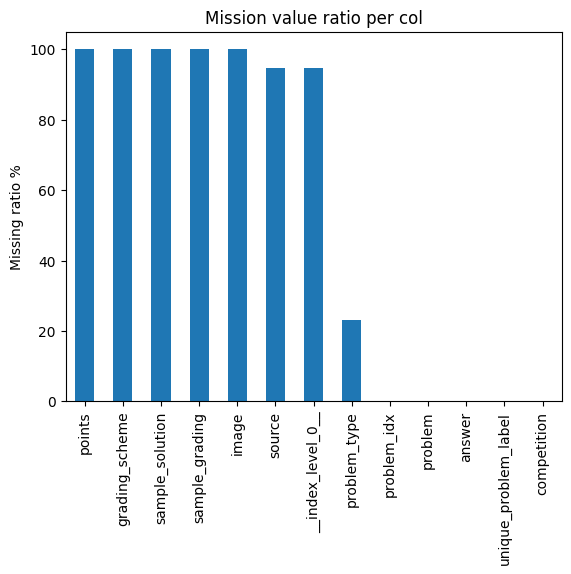

In [149]:
from data_processing_utils import find_missing_value_ratios, plot_missing
miss_problem = find_missing_value_ratios(df_problem)
miss_problem
plot_missing(miss_problem)

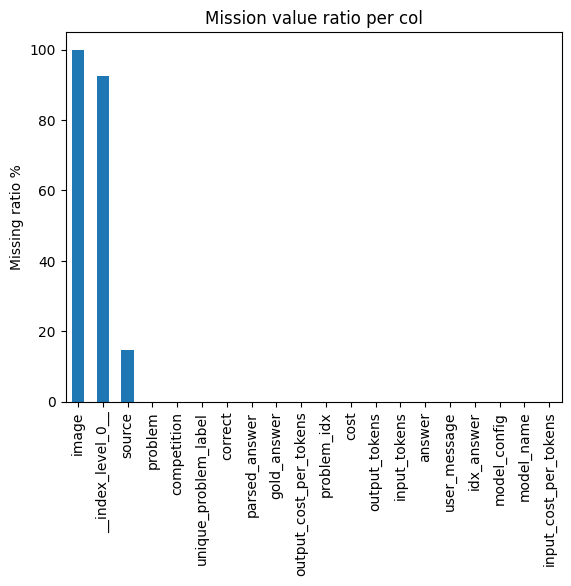

In [150]:
miss_outputs = find_missing_value_ratios(df_outputs)
miss_outputs
plot_missing(miss_outputs)

Now we will drop column with missing value ration over 25%

In [151]:
from data_processing_utils import prune_missing
df_problem = prune_missing(df_problem, missing_ratio=miss_problem, threshold=0.25)
df_problem.columns

Index(['problem_type', 'problem_idx', 'problem', 'answer',
       'unique_problem_label', 'competition'],
      dtype='object')

In [152]:
df_outputs = prune_missing(df_outputs, missing_ratio=miss_outputs, threshold=0.25)
df_outputs.columns

Index(['source', 'problem', 'competition', 'unique_problem_label', 'correct',
       'parsed_answer', 'gold_answer', 'output_cost_per_tokens', 'problem_idx',
       'cost', 'output_tokens', 'input_tokens', 'answer', 'user_message',
       'idx_answer', 'model_config', 'model_name', 'input_cost_per_tokens'],
      dtype='object')

## Data analysis
In this section we will: 
- Give each problem a difficulty score by arranging them in terms of 10% percentiles
- Discuss and propose two solutions to handle the problem of the 25 % missing values of the category label in the pruned dataset
- Do the actual selection of problems to run our promt methond for the demo

### Difficulty score / grouping by 10% percentile
For this project, we wish to select a fitting subset of problems to test our promting hypothesis on. However, not all problems are equally difficult. One way to measure difficulty is to look at how many models got an problem right. In other words,  the correct prediction to wrong prediction ratio. When doing this we can then group problems by their 10 percent percentile. 



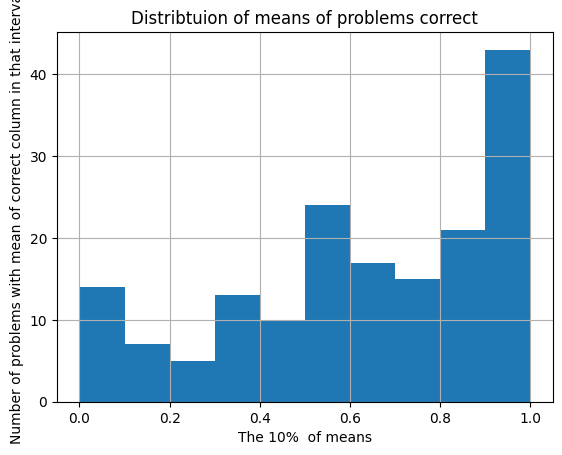

In [153]:
import matplotlib.pyplot as plt
bins = 10
CORRECT = "correct"
grouped = df_outputs.groupby(UNIQUE_PROBLEM_LABEL)[CORRECT].mean()

h = grouped.hist(bins=bins)
plt.xlabel(f"The {bins}%  of means")
plt.ylabel("Number of problems with mean of correct column in that interval")
plt.title("Distribtuion of means of problems correct")
plt.show()

In this plot, we see that there are problems which none or a few models got right in all attempts (the first 10% percentile) and problems in the 10th 10% percetile, for which  most models got right in at least 40% of the time. 

This inspires make difficulty feature from 1-10 in decending order of difficulty: 1 denotes that the problem is in the firt percentile (hardest), 10 denotes that the proble is in the 10th prercentile (easiest). 

In [154]:
from data_analysis import create_ten_percentile_group
df_outputs = create_ten_percentile_group(df_outputs)
df_outputs.head(5)[["unique_problem_label", "ten_percentile_group"]]

,unique_problem_label,ten_percentile_group
0,MathArena/apex_2025: 12,1
1,MathArena/apex_2025: 12,1
2,MathArena/apex_2025: 12,1
3,MathArena/apex_2025: 12,1
4,MathArena/apex_2025: 12,1


#### Saving the dataset
We can now save these processed datasets. We will just store this locally and not on git (thus the .gitignore). 

To get the data, oen can just run the entire main.ipynb notebool. 


In [ ]:
from data_analysis import PROBLEM_PATH, OUTPUTS_PATH
df_problem.to_csv(PROBLEM_PATH)
df_outputs.to_csv(OUTPUTS_PATH)

### Catagory label
While the difficucly feature is nice, it would be benefitial to have more features in order to judge the models performance and to select a proper subset of problems for this project. One promising feature is `category`. However, as we have already shown, 25% of the pruned dataset does not contains the label category. What is worse is, that the problems are on such a high level of mathematics, that we cannot properly label the rest of the 75 % ourselves. 

Another intersting fact about the catogry labels is, that it not a single class problem but a multi class problem - i.e. each problem can have multiple different categries. See the following bar chart




<string>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



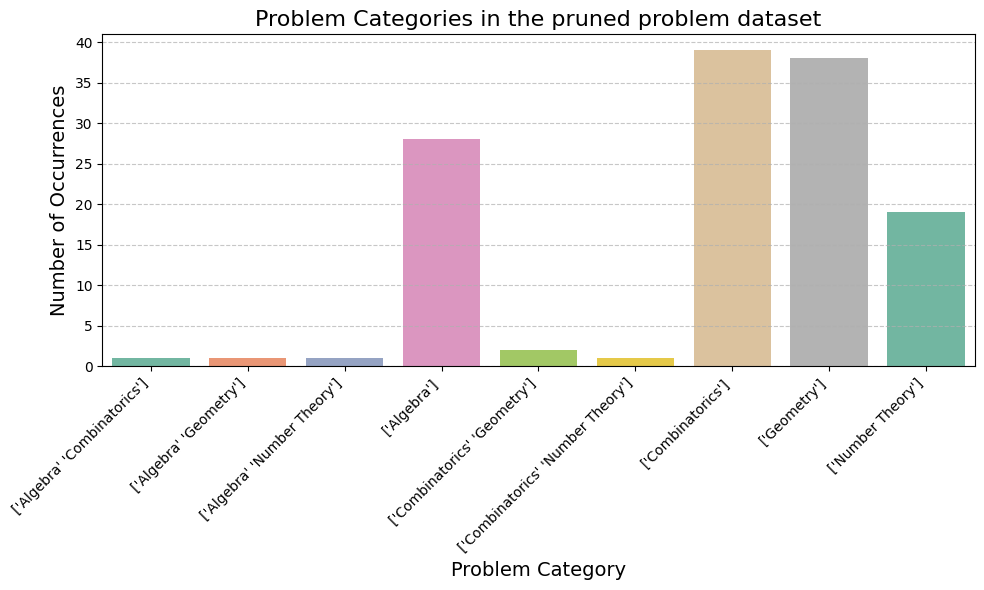

In [183]:
from data_analysis import visualize_problem_counts, count_categories
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

counts = count_categories(df_problem)
visualize_problem_counts(counts)



We tried a few approach to generate category labels for the rest of the dataset. One approach was just naive "look for words that are common in ex combinatorics" and use that to predict the category. This did, as expected not have a very high accuray. See appendix for detials. 

Another attempt was to use incontext learning, where we feed the model some examples of problems and cateogory, and then ask it to predict the catory on some test set (a split on the pruned dataset). This seems promisng  so far in terms of accuracy (73% accurary on testset) on a so we might use it for P3, but is still a work in progress. 

For now, we just base our problem selection only on the problem difficulty level. 

### Select problems for demo

Here we list all the different models in the compoetition

In [156]:
from data_analysis import MODEL_NAME
model_names = list(df_outputs[MODEL_NAME].unique())
model_names

['Claude-Sonnet-4.5 (Think)',
 'DeepSeek-v3.1 (Think)',
 'DeepSeek-R1-0528',
 'DeepSeek-v3.2 (Think)',
 'gemini-2.5-pro',
 'GPT-5 (high)',
 'GPT OSS 120B (high)',
 'GPT-5-mini (high)',
 'GPT-5 (High) Agent',
 'GLM 4.6',
 'GLM 4.5',
 'Qwen3-235B-2507-Think',
 'Grok 4 Fast (Reasoning)',
 'Grok 4',
 'Claude-Opus-4.0 (Think)',
 'Claude-3.7-Sonnet (Think)',
 'Claude-3.5-Sonnet',
 'DeepSeek-R1-Distill-14B',
 'DeepSeek-R1-Distill-32B',
 'DeepSeek-R1-Distill-1.5B',
 'DeepSeek-V3',
 'DeepSeek-R1-Distill-70B',
 'DeepSeek-V3-03-24',
 'DeepSeek-R1',
 'Llama-4-Maverick',
 'gemini-2.5-flash (think)',
 'gemini-2.5-pro-05-06',
 'gemini-2.0-pro',
 'gemini-2.0-flash',
 'gemini-2.0-flash-thinking',
 'GPT OSS 20B (high)',
 'o3 (high)',
 'o3-mini (low)',
 'o3-mini (medium)',
 'o4-mini (medium)',
 'o4-mini (high)',
 'o4-mini (low)',
 'o1 (medium)',
 'GPT-5-nano (high)',
 'gpt-4o',
 'o3-mini (high)',
 'GLM 4.5 Air',
 'LIMO',
 's1.1-32B',
 'K2-Think',
 'OpenThinker-32B',
 'Phi-4-reasoning-plus',
 'Qwen3-235B-

Next step is to pick a model and find all the problems it could not solve. 
First we select one data related to a single model. Ex Deepseek R1 (which is also the one we use in the demo)

In [157]:
from data_analysis import select_only_single_model_stats
DEEPSEEK_R1 = 'DeepSeek-R1'
df_outputs_deepseek = select_only_single_model_stats(df_outputs, model_name=DEEPSEEK_R1)
print("Number of DeepSeek-R1 responses", len(df_outputs_deepseek))
df_outputs_deepseek.head(5)

Number of DeepSeek-R1 responses 480


,source,problem,competition,unique_problem_label,correct,parsed_answer,gold_answer,output_cost_per_tokens,problem_idx,cost,output_tokens,input_tokens,answer,user_message,idx_answer,model_config,model_name,input_cost_per_tokens,ten_percentile_group
1440,None,"Let $x_1, x_2, x_3, \ldots$ be a sequence of r...",MathArena/aime_2025_outputs,MathArena/aime_2025: 28,False,36,248,2.18,28,0.039087,17893.0,161.0,"Given the sequence \( x_1, x_2, x_3, \ldots \)...","Please reason step by step, and put your final...",0,deepseek/deepseek_r1,DeepSeek-R1,0.5,2
1441,None,"Let $x_1, x_2, x_3, \ldots$ be a sequence of r...",MathArena/aime_2025_outputs,MathArena/aime_2025: 28,False,48,248,2.18,28,0.040517,18549.0,161.0,Given the sequence \( x_1 = \frac{25}{11} \) a...,"Please reason step by step, and put your final...",1,deepseek/deepseek_r1,DeepSeek-R1,0.5,2
1442,None,"Let $x_1, x_2, x_3, \ldots$ be a sequence of r...",MathArena/aime_2025_outputs,MathArena/aime_2025: 28,False,208,248,2.18,28,0.045235,20713.0,161.0,"Given the sequence \( x_1, x_2, x_3, \ldots \)...","Please reason step by step, and put your final...",2,deepseek/deepseek_r1,DeepSeek-R1,0.5,2
1443,None,"Let $x_1, x_2, x_3, \ldots$ be a sequence of r...",MathArena/aime_2025_outputs,MathArena/aime_2025: 28,False,208,248,2.18,28,0.045581,20872.0,161.0,The problem involves a sequence defined by \( ...,"Please reason step by step, and put your final...",3,deepseek/deepseek_r1,DeepSeek-R1,0.5,2
1444,None,"From an unlimited supply of $1$-cent coins, $1...",MathArena/aime_2025_outputs,MathArena/aime_2025: 23,True,610,610,2.18,23,0.023121,10537.0,301.0,To determine the number of values \( N \) betw...,"Please reason step by step, and put your final...",0,deepseek/deepseek_r1,DeepSeek-R1,0.5,5


Now we can find all the problems that this model could not solve. In MathArea, each model have multiple attempts - meaning for the same problem, there are multiple rows with the same model trying to solve it. For an effective demonstration of our promting strategy, we want to select only the problems that the model never got right even once. 

To do this, we select all the `ùnique_problem_label` values, where the coresponding rows `correct` column is `False`. Then we do the same but where the `correct` is `True`. The set difference of this yeilds problems that has only `False` in the correct column for that model

In [184]:
from data_analysis import select_only_false

df_outputs_deepseek_F =  select_only_false(df_outputs_deepseek)

print("Number of only false answer problems", len(df_outputs_deepseek_F))

Number of only false answer problems 100


Now we select problems were each problem has a unique difficulty / unqiue ten_percentile_group value. 

In [187]:
from data_analysis import select_problem_sample, TEN_PERCENTILE_GROUP

select_problem_sample(df_outputs_deepseek_F, df_problem)

,source,problem,competition,unique_problem_label,correct,parsed_answer,gold_answer,output_cost_per_tokens,problem_idx,cost,output_tokens,input_tokens,answer,user_message,idx_answer,model_config,model_name,input_cost_per_tokens,ten_percentile_group
1440,None,"Let $x_1, x_2, x_3, \ldots$ be a sequence of r...",MathArena/aime_2025_outputs,MathArena/aime_2025: 28,False,36,248,2.18,28,0.039087,17893.0,161.0,"Given the sequence \( x_1, x_2, x_3, \ldots \)...","Please reason step by step, and put your final...",0,deepseek/deepseek_r1,DeepSeek-R1,0.5,2
1484,None,"Let $ABCDE$ be a convex pentagon with $AB=14$,...",MathArena/aime_2025_outputs,MathArena/aime_2025: 14,False,45,60,2.18,14,0.158214,72436.0,608.0,Given a convex pentagon \(ABCDE\) with side le...,"Please reason step by step, and put your final...",0,deepseek/deepseek_r1,DeepSeek-R1,0.5,1
1472,None,Let $\triangle A B C$ be an equilateral triang...,MathArena/hmmt_feb_2025_outputs,MathArena/hmmt_feb_2025: 25,False,sqrt(11),\sqrt{23}-2 \sqrt{3},2.18,25,0.030148,13805.0,106.0,Given an equilateral triangle \( \triangle ABC...,"Please reason step by step, and put your final...",0,deepseek/deepseek_r1,DeepSeek-R1,0.5,3
1524,None,Define $\operatorname{sgn}(x)$ to be $1$ when ...,MathArena/hmmt_feb_2025_outputs,MathArena/hmmt_feb_2025: 8,False,4/11,1-\frac{2}{\pi},2.18,8,0.029261,13398.0,107.0,To compute the infinite sum \(\sum_{n=1}^{\inf...,"Please reason step by step, and put your final...",0,deepseek/deepseek_r1,DeepSeek-R1,0.5,4
972,None,"Alice has $10$ gifts $g_{1}, g_{2}, \ldots, g_...",MathArena/brumo_2025_outputs,MathArena/brumo_2025: 12,False,123,125,2.18,12,0.035888,16432.0,133.0,"Alice has 10 gifts and 10 friends, where each ...","Please reason step by step, and put your final...",0,deepseek/deepseek_r1,DeepSeek-R1,0.5,5


We also created a small short cut

In [188]:
from data_analysis import select_problem_sample_for_model
select_problem_sample_for_model(DEEPSEEK_R1)

,Unnamed: 0,source,problem,competition,unique_problem_label,correct,parsed_answer,gold_answer,output_cost_per_tokens,problem_idx,cost,output_tokens,input_tokens,answer,user_message,idx_answer,model_config,model_name,input_cost_per_tokens,ten_percentile_group
3348,1440,NaN,"Let $x_1, x_2, x_3, \ldots$ be a sequence of r...",MathArena/aime_2025_outputs,MathArena/aime_2025: 28,False,36,248,2.18,28,0.039087,17893.0,161.0,"Given the sequence \( x_1, x_2, x_3, \ldots \)...","Please reason step by step, and put your final...",0,deepseek/deepseek_r1,DeepSeek-R1,0.5,2
3392,1484,NaN,"Let $ABCDE$ be a convex pentagon with $AB=14$,...",MathArena/aime_2025_outputs,MathArena/aime_2025: 14,False,45,60,2.18,14,0.158214,72436.0,608.0,Given a convex pentagon \(ABCDE\) with side le...,"Please reason step by step, and put your final...",0,deepseek/deepseek_r1,DeepSeek-R1,0.5,1
13220,1472,NaN,Let $\triangle A B C$ be an equilateral triang...,MathArena/hmmt_feb_2025_outputs,MathArena/hmmt_feb_2025: 25,False,sqrt(11),\sqrt{23}-2 \sqrt{3},2.18,25,0.030148,13805.0,106.0,Given an equilateral triangle \( \triangle ABC...,"Please reason step by step, and put your final...",0,deepseek/deepseek_r1,DeepSeek-R1,0.5,3
13272,1524,NaN,Define $\operatorname{sgn}(x)$ to be $1$ when ...,MathArena/hmmt_feb_2025_outputs,MathArena/hmmt_feb_2025: 8,False,4/11,1-\frac{2}{\pi},2.18,8,0.029261,13398.0,107.0,To compute the infinite sum \(\sum_{n=1}^{\inf...,"Please reason step by step, and put your final...",0,deepseek/deepseek_r1,DeepSeek-R1,0.5,4
22520,972,NaN,"Alice has $10$ gifts $g_{1}, g_{2}, \ldots, g_...",MathArena/brumo_2025_outputs,MathArena/brumo_2025: 12,False,123,125,2.18,12,0.035888,16432.0,133.0,"Alice has 10 gifts and 10 friends, where each ...","Please reason step by step, and put your final...",0,deepseek/deepseek_r1,DeepSeek-R1,0.5,5


## Demo of promt strategy

For the demo, we reference the notebook `multi_agent_demo.ipynb` (we know the project description specified only one notebook main.ipynb, but we had already ran the experiments in that notebook. We apologize for this, but hope it is not an inconvenience)